In [3]:
from pathlib import Path

# ============================================================
# PROJECT AND DATASET PATHS
# ============================================================

# Project root
PROJECT_ROOT = Path.cwd().parent

# Grocery Store Dataset
DATASET_ROOT = PROJECT_ROOT / "dataset" / "GroceryStoreDataset-master" / "dataset"

# Dataset splits
TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

# Label files
CLASSES_FILE = DATASET_ROOT / "classes.csv"
TRAIN_FILE = DATASET_ROOT / "train.txt"
VAL_FILE = DATASET_ROOT / "val.txt"
TEST_FILE = DATASET_ROOT / "test.txt"

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset root:")
print(DATASET_ROOT)

print("\nChecking required paths...")

required_paths = {
    "Train directory": TRAIN_DIR,
    "Validation directory": VAL_DIR,
    "Test directory": TEST_DIR,
    "Classes CSV": CLASSES_FILE,
    "Train labels": TRAIN_FILE,
    "Validation labels": VAL_FILE,
    "Test labels": TEST_FILE,
}

for name, path in required_paths.items():
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:8} {name}: {path}")

Project root:
d:\semester_7\dip\Project\smart-supermarket-product-identification

Dataset root:
d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking required paths...
OK       Train directory: d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train
OK       Validation directory: d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val
OK       Test directory: d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test
OK       Classes CSV: d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv
OK       Train labels: d:\semester_7\dip\Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train.txt
OK       Validation labels: d:\semester_7\dip\Projec

In [4]:
import pandas as pd

# ============================================================
# INSPECT CLASSES.CSV
# ============================================================

classes_df = pd.read_csv(CLASSES_FILE)

print("Classes CSV shape:")
print(classes_df.shape)

print("\nColumn names:")
print(classes_df.columns.tolist())

print("\nFirst 10 rows:")
display(classes_df.head(10))

Classes CSV shape:
(81, 6)

Column names:
['Class Name (str)', 'Class ID (int)', 'Coarse Class Name (str)', 'Coarse Class ID (int)', 'Iconic Image Path (str)', 'Product Description Path (str)']

First 10 rows:


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int),Iconic Image Path (str),Product Description Path (str)
0,Golden-Delicious,0,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Go...,/iconic-images-and-descriptions/Fruit/Apple/Go...
1,Granny-Smith,1,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Gr...,/iconic-images-and-descriptions/Fruit/Apple/Gr...
2,Pink-Lady,2,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Pi...,/iconic-images-and-descriptions/Fruit/Apple/Pi...
3,Red-Delicious,3,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Re...,/iconic-images-and-descriptions/Fruit/Apple/Re...
4,Royal-Gala,4,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Ro...,/iconic-images-and-descriptions/Fruit/Apple/Ro...
5,Avocado,5,Avocado,1,/iconic-images-and-descriptions/Fruit/Avocado/...,/iconic-images-and-descriptions/Fruit/Avocado/...
6,Banana,6,Banana,2,/iconic-images-and-descriptions/Fruit/Banana/B...,/iconic-images-and-descriptions/Fruit/Banana/B...
7,Kiwi,7,Kiwi,3,/iconic-images-and-descriptions/Fruit/Kiwi/Kiw...,/iconic-images-and-descriptions/Fruit/Kiwi/Kiw...
8,Lemon,8,Lemon,4,/iconic-images-and-descriptions/Fruit/Lemon/Le...,/iconic-images-and-descriptions/Fruit/Lemon/Le...
9,Lime,9,Lime,5,/iconic-images-and-descriptions/Fruit/Lime/Lim...,/iconic-images-and-descriptions/Fruit/Lime/Lim...


In [5]:
# ============================================================
# VERIFY CLASS AND COARSE-CLASS STRUCTURE
# ============================================================

class_name_col = "Class Name (str)"
class_id_col = "Class ID (int)"
coarse_name_col = "Coarse Class Name (str)"
coarse_id_col = "Coarse Class ID (int)"

# Number of fine-grained classes
num_fine_classes = classes_df[class_id_col].nunique()

# Number of coarse classes
num_coarse_classes = classes_df[coarse_id_col].nunique()

# Check for duplicate class IDs
duplicate_class_ids = classes_df[class_id_col].duplicated().sum()

# Check for duplicate class names
duplicate_class_names = classes_df[class_name_col].duplicated().sum()

# Check whether class IDs are 0 ... N-1
expected_class_ids = set(range(num_fine_classes))
actual_class_ids = set(classes_df[class_id_col])

class_ids_contiguous = actual_class_ids == expected_class_ids

print("DATASET CLASS STRUCTURE")
print("=" * 50)

print(f"Fine-grained classes       : {num_fine_classes}")
print(f"Coarse-grained categories : {num_coarse_classes}")

print(f"\nDuplicate class IDs       : {duplicate_class_ids}")
print(f"Duplicate class names     : {duplicate_class_names}")

print(f"\nClass IDs are 0 to {num_fine_classes - 1}: {class_ids_contiguous}")

print("\nCoarse categories:")
print(
    classes_df[
        [coarse_id_col, coarse_name_col]
    ]
    .drop_duplicates()
    .sort_values(coarse_id_col)
    .to_string(index=False)
)

DATASET CLASS STRUCTURE
Fine-grained classes       : 81
Coarse-grained categories : 43

Duplicate class IDs       : 0
Duplicate class names     : 0

Class IDs are 0 to 80: True

Coarse categories:
 Coarse Class ID (int) Coarse Class Name (str)
                     0                   Apple
                     1                 Avocado
                     2                  Banana
                     3                    Kiwi
                     4                   Lemon
                     5                    Lime
                     6                   Mango
                     7                   Melon
                     8               Nectarine
                     9                  Orange
                    10                  Papaya
                    11           Passion-Fruit
                    12                   Peach
                    13                    Pear
                    14               Pineapple
                    15                    Plum
    

In [6]:
# ============================================================
# INSPECT TRAIN / VALIDATION / TEST LABEL FILES
# ============================================================

def inspect_label_file(file_path, split_name):
    print(f"\n{'=' * 60}")
    print(f"{split_name.upper()} LABEL FILE")
    print(f"{'=' * 60}")
    
    with open(file_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    
    print(f"Number of entries: {len(lines)}")
    
    print("\nFirst 5 entries:")
    for line in lines[:5]:
        print(line)
    
    return lines


train_lines = inspect_label_file(TRAIN_FILE, "train")
val_lines = inspect_label_file(VAL_FILE, "validation")
test_lines = inspect_label_file(TEST_FILE, "test")


TRAIN LABEL FILE
Number of entries: 2640

First 5 entries:
train/Fruit/Apple/Golden-Delicious/Golden-Delicious_001.jpg, 0, 0
train/Fruit/Apple/Golden-Delicious/Golden-Delicious_002.jpg, 0, 0
train/Fruit/Apple/Golden-Delicious/Golden-Delicious_003.jpg, 0, 0
train/Fruit/Apple/Golden-Delicious/Golden-Delicious_004.jpg, 0, 0
train/Fruit/Apple/Golden-Delicious/Golden-Delicious_005.jpg, 0, 0

VALIDATION LABEL FILE
Number of entries: 296

First 5 entries:
val/Fruit/Apple/Golden-Delicious/Golden-Delicious_001.jpg, 0, 0
val/Fruit/Apple/Golden-Delicious/Golden-Delicious_002.jpg, 0, 0
val/Fruit/Apple/Golden-Delicious/Golden-Delicious_003.jpg, 0, 0
val/Fruit/Apple/Golden-Delicious/Golden-Delicious_004.jpg, 0, 0
val/Fruit/Apple/Golden-Delicious/Golden-Delicious_005.jpg, 0, 0

TEST LABEL FILE
Number of entries: 2485

First 5 entries:
test/Fruit/Apple/Golden-Delicious/Golden-Delicious_001.jpg, 0, 0
test/Fruit/Apple/Golden-Delicious/Golden-Delicious_002.jpg, 0, 0
test/Fruit/Apple/Golden-Delicious/Gol

In [9]:
# ============================================================
# VALIDATE DATASET LABELS AND IMAGE PATHS
# ============================================================

def parse_label_file(file_path):
    """
    Parse dataset label file.

    Format:
    image_path, fine_class_id, coarse_class_id
    """
    records = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = [part.strip() for part in line.split(",")]

            if len(parts) != 3:
                raise ValueError(
                    f"Unexpected format in {file_path.name}, "
                    f"line {line_number}: {line}"
                )

            image_path, fine_id, coarse_id = parts

            records.append({
                "image_path": image_path,
                "fine_id": int(fine_id),
                "coarse_id": int(coarse_id),
            })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# Load all three splits
# ------------------------------------------------------------

train_df = parse_label_file(TRAIN_FILE)
val_df = parse_label_file(VAL_FILE)
test_df = parse_label_file(TEST_FILE)

print("LABEL DATAFRAME SHAPES")
print("=" * 50)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

print("\nTotal images:")
print(f"{len(train_df) + len(val_df) + len(test_df)}")


# ------------------------------------------------------------
# Check class IDs
# ------------------------------------------------------------

print("\nCLASS ID VALIDATION")
print("=" * 50)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    invalid_fine = df[
        ~df["fine_id"].isin(classes_df[class_id_col])
    ]

    invalid_coarse = df[
        ~df["coarse_id"].isin(classes_df[coarse_id_col])
    ]

    print(f"\n{split_name}")
    print(f"Invalid fine-class IDs   : {len(invalid_fine)}")
    print(f"Invalid coarse-class IDs : {len(invalid_coarse)}")


# ------------------------------------------------------------
# Verify fine → coarse mapping
# ------------------------------------------------------------

print("\nFINE → COARSE MAPPING VALIDATION")
print("=" * 50)

class_to_coarse = dict(
    zip(
        classes_df[class_id_col],
        classes_df[coarse_id_col]
    )
)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    mapping_errors = df[
        df.apply(
            lambda row:
            class_to_coarse.get(row["fine_id"]) != row["coarse_id"],
            axis=1
        )
    ]

    print(
        f"{split_name} mapping errors: "
        f"{len(mapping_errors)}"
    )


# ------------------------------------------------------------
# Verify image files actually exist
# ------------------------------------------------------------

print("\nIMAGE PATH VALIDATION")
print("=" * 50)

def check_image_paths(df, split_name):
    missing = []

    for relative_path in df["image_path"]:
        full_path = DATASET_ROOT / relative_path

        if not full_path.exists():
            missing.append(relative_path)

    print(f"{split_name} missing images: {len(missing)}")

    if missing:
        print("First missing files:")
        for path in missing[:10]:
            print(path)

    return missing


train_missing = check_image_paths(train_df, "Train")
val_missing = check_image_paths(val_df, "Validation")
test_missing = check_image_paths(test_df, "Test")

LABEL DATAFRAME SHAPES
Train      : (2640, 3)
Validation : (296, 3)
Test       : (2485, 3)

Total images:
5421

CLASS ID VALIDATION

Train
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0

Validation
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0

Test
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0

FINE → COARSE MAPPING VALIDATION
Train mapping errors: 0
Validation mapping errors: 0
Test mapping errors: 0

IMAGE PATH VALIDATION
Train missing images: 0
Validation missing images: 0
Test missing images: 0


In [10]:
# ============================================================
# FINE-GRAINED CLASS DISTRIBUTION
# ============================================================

# Create class-name lookup
class_name_lookup = dict(
    zip(
        classes_df[class_id_col],
        classes_df[class_name_col]
    )
)


def class_distribution(df):
    """Return image count for every fine-grained class."""
    counts = (
        df["fine_id"]
        .value_counts()
        .sort_index()
    )

    distribution = pd.DataFrame({
        "Class ID": counts.index,
        "Class Name": [
            class_name_lookup[class_id]
            for class_id in counts.index
        ],
        "Image Count": counts.values
    })

    return distribution


train_distribution = class_distribution(train_df)
val_distribution = class_distribution(val_df)
test_distribution = class_distribution(test_df)


# ------------------------------------------------------------
# Combine distributions
# ------------------------------------------------------------

distribution_df = classes_df[
    [class_id_col, class_name_col]
].copy()

distribution_df.columns = [
    "Class ID",
    "Class Name"
]

distribution_df["Train"] = (
    distribution_df["Class ID"]
    .map(train_distribution.set_index("Class ID")["Image Count"])
    .fillna(0)
    .astype(int)
)

distribution_df["Validation"] = (
    distribution_df["Class ID"]
    .map(val_distribution.set_index("Class ID")["Image Count"])
    .fillna(0)
    .astype(int)
)

distribution_df["Test"] = (
    distribution_df["Class ID"]
    .map(test_distribution.set_index("Class ID")["Image Count"])
    .fillna(0)
    .astype(int)
)

distribution_df["Total"] = (
    distribution_df["Train"]
    + distribution_df["Validation"]
    + distribution_df["Test"]
)


print("FINE-GRAINED CLASS DISTRIBUTION")
print("=" * 70)

print(f"Number of classes: {len(distribution_df)}")

print("\nTraining:")
print(f"  Minimum images/class : {distribution_df['Train'].min()}")
print(f"  Maximum images/class : {distribution_df['Train'].max()}")
print(f"  Mean images/class    : {distribution_df['Train'].mean():.2f}")

print("\nValidation:")
print(f"  Minimum images/class : {distribution_df['Validation'].min()}")
print(f"  Maximum images/class : {distribution_df['Validation'].max()}")
print(f"  Mean images/class    : {distribution_df['Validation'].mean():.2f}")

print("\nTest:")
print(f"  Minimum images/class : {distribution_df['Test'].min()}")
print(f"  Maximum images/class : {distribution_df['Test'].max()}")
print(f"  Mean images/class    : {distribution_df['Test'].mean():.2f}")

print("\nComplete distribution:")
display(distribution_df)

FINE-GRAINED CLASS DISTRIBUTION
Number of classes: 81

Training:
  Minimum images/class : 16
  Maximum images/class : 70
  Mean images/class    : 32.59

Validation:
  Minimum images/class : 0
  Maximum images/class : 6
  Mean images/class    : 3.65

Test:
  Minimum images/class : 10
  Maximum images/class : 68
  Mean images/class    : 30.68

Complete distribution:


,Class ID,Class Name,Train,Validation,Test,Total
0,0,Golden-Delicious,45,6,45,96
1,1,Granny-Smith,59,6,58,123
2,2,Pink-Lady,59,5,59,123
3,3,Red-Delicious,50,0,50,100
4,4,Royal-Gala,65,5,64,134
...,...,...,...,...,...,...
76,76,Red-Beet,18,5,17,40
77,77,Beef-Tomato,34,3,10,47
78,78,Regular-Tomato,50,0,47,97
79,79,Vine-Tomato,43,5,43,91


In [11]:
# ============================================================
# MOST AND LEAST REPRESENTED CLASSES
# ============================================================

print("TRAINING SET — LEAST REPRESENTED CLASSES")
print("=" * 60)

display(
    distribution_df
    .sort_values("Train")
    [["Class ID", "Class Name", "Train"]]
    .head(10)
)


print("\nTRAINING SET — MOST REPRESENTED CLASSES")
print("=" * 60)

display(
    distribution_df
    .sort_values("Train", ascending=False)
    [["Class ID", "Class Name", "Train"]]
    .head(10)
)


print("\nVALIDATION SET — CLASSES WITH ZERO IMAGES")
print("=" * 60)

val_zero_classes = distribution_df[
    distribution_df["Validation"] == 0
]

print(f"Number of classes without validation images: {len(val_zero_classes)}")

if len(val_zero_classes) > 0:
    display(
        val_zero_classes[
            ["Class ID", "Class Name"]
        ]
    )


print("\nTEST SET — CLASSES WITH ZERO IMAGES")
print("=" * 60)

test_zero_classes = distribution_df[
    distribution_df["Test"] == 0
]

print(f"Number of classes without test images: {len(test_zero_classes)}")

TRAINING SET — LEAST REPRESENTED CLASSES


,Class ID,Class Name,Train
59,59,Asparagus,16
76,76,Red-Beet,18
73,73,Floury-Potato,18
30,30,God-Morgon-Apple-Juice,19
47,47,Arla-Sour-Cream,19
65,65,Ginger,19
61,61,Cabbage,19
32,32,God-Morgon-Orange-Red-Grapefruit-Juice,20
58,58,Yoggi-Vanilla-Yoghurt,20
37,37,Tropicana-Mandarin-Morning,20



TRAINING SET — MOST REPRESENTED CLASSES


,Class ID,Class Name,Train
27,27,Satsumas,70
4,4,Royal-Gala,65
2,2,Pink-Lady,59
1,1,Granny-Smith,59
16,16,Orange,57
78,78,Regular-Tomato,50
3,3,Red-Delicious,50
14,14,Watermelon,46
7,7,Kiwi,46
0,0,Golden-Delicious,45



VALIDATION SET — CLASSES WITH ZERO IMAGES
Number of classes without validation images: 21


,Class ID,Class Name
3,3,Red-Delicious
15,15,Nectarine
17,17,Papaya
20,20,Anjou
22,22,Kaiser
24,24,Plum
34,34,Tropicana-Apple-Juice
35,35,Tropicana-Golden-Grapefruit
36,36,Tropicana-Juice-Smooth
37,37,Tropicana-Mandarin-Morning



TEST SET — CLASSES WITH ZERO IMAGES
Number of classes without test images: 0


In [12]:
# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================

train_min = distribution_df["Train"].min()
train_max = distribution_df["Train"].max()

if train_min > 0:
    imbalance_ratio = train_max / train_min
else:
    imbalance_ratio = float("inf")

print("CLASS IMBALANCE")
print("=" * 50)

print(f"Minimum training samples/class : {train_min}")
print(f"Maximum training samples/class : {train_max}")
print(f"Imbalance ratio                : {imbalance_ratio:.2f}")

if imbalance_ratio <= 1.5:
    print("\nInterpretation: Training distribution is relatively balanced.")
elif imbalance_ratio <= 3:
    print("\nInterpretation: Moderate class imbalance is present.")
else:
    print("\nInterpretation: Significant class imbalance is present.")

CLASS IMBALANCE
Minimum training samples/class : 16
Maximum training samples/class : 70
Imbalance ratio                : 4.38

Interpretation: Significant class imbalance is present.


Matplotlib is building the font cache; this may take a moment.


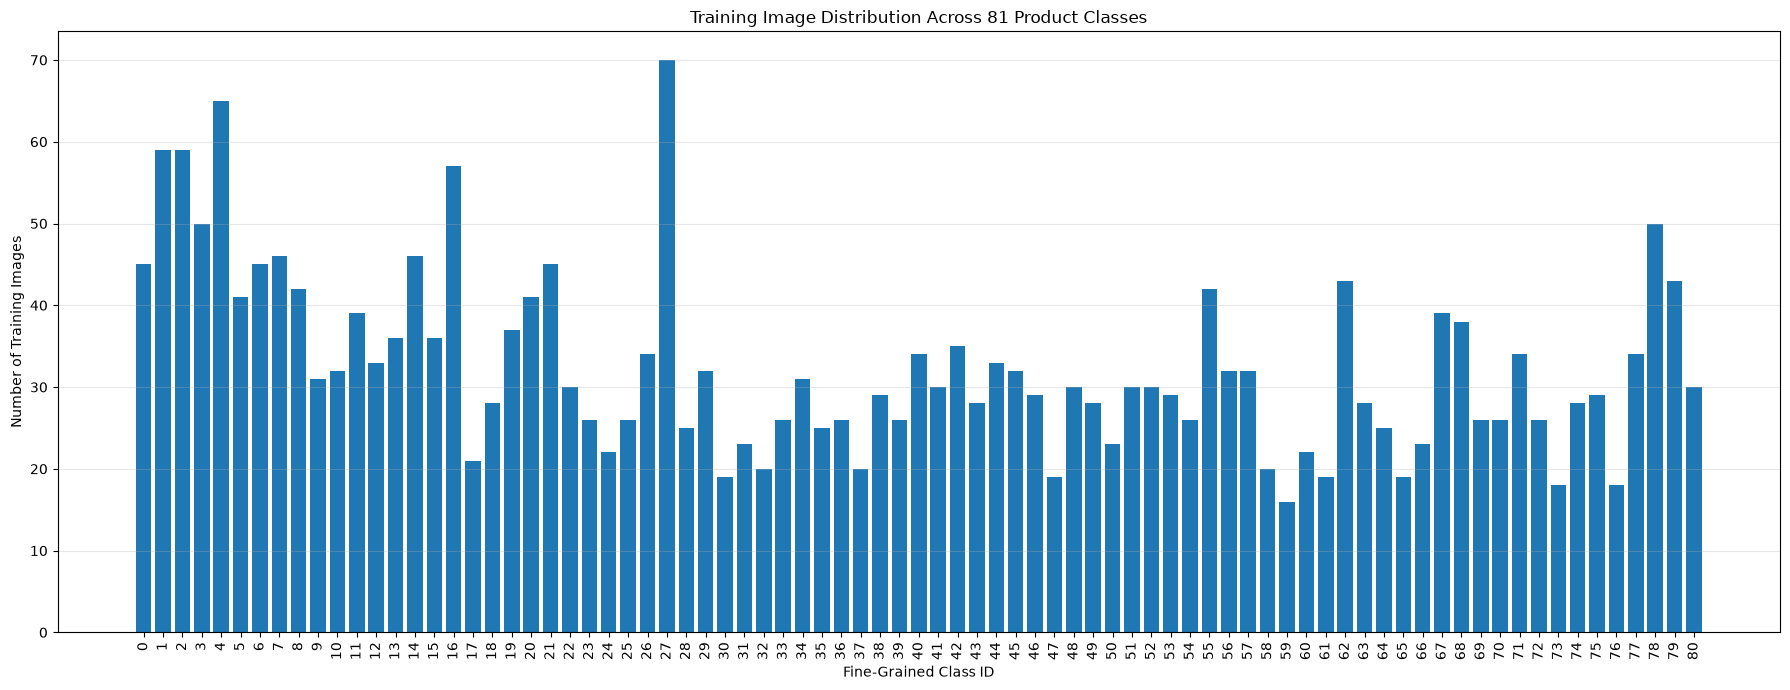

In [15]:
# ============================================================
# TRAINING CLASS DISTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 7))

plt.bar(
    distribution_df["Class ID"],
    distribution_df["Train"]
)

plt.xlabel("Fine-Grained Class ID")
plt.ylabel("Number of Training Images")
plt.title("Training Image Distribution Across 81 Product Classes")

plt.xticks(
    distribution_df["Class ID"],
    rotation=90
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()